In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from Pruning.pruning_CSSP import *
from Pruning.pruning_filter import *
from Pruning.magnitude_pruning import *
from scipy.linalg import solve, qr
import numpy as np
from Plot import *
import random
from model import *
import contextlib
import io
import importlib

# Transform to tensor
dataset_transform = transforms.Compose([
    transforms.ToTensor(),                 
    #transforms.Normalize((0.1307,), (0.3081,))  # Normalization 
])

train_dataset = datasets.MNIST(
    root = "./data",      
    train = True,         
    download = True,      
    transform = dataset_transform
)

test_dataset = datasets.MNIST(
    root = "./data",
    train = False,        
    download = True,
    transform = dataset_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

<img src="nn4MNIST.png" alt="nn" width="600">

In [2]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.mps.is_available() else "cpu")
#device = torch.device("cpu")

class Model2(nn.Module):
    def __init__(self):
        super(Model2, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.model(x)
        return x
    

model2 = Model2().to(device)

# loss functiom & optimizer
loss_fun = nn.CrossEntropyLoss()
optimizer = optim.SGD(model2.parameters(), lr=0.1, momentum=0.9)

train_data_size = len(train_dataset)
test_data_size = len(test_dataset)

In [3]:
epoch = 5

for i in range(epoch):
    print("-------Epoch {}-------".format(i+1))
    # train
    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        outputs = model2(imgs)
        loss = loss_fun(outputs, targets)

        # optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # test
    total_test_loss = 0
    total_accuracy = 0
    wrong_indices = []
    base_idx = 0
    with torch.no_grad():
        for imgs, targets in test_loader:
            batch_size = targets.size(0)
            imgs = imgs.to(device)
            targets = targets.to(device)
            outputs = model2(imgs)

            loss0 = loss_fun(outputs, targets)
            total_test_loss = total_test_loss + loss0.item()

            accuracy = (outputs.argmax(1) == targets).sum().item()
            total_accuracy = total_accuracy + accuracy

            # Record indices of misclassified samples
            if i == epoch - 1:  # Only record for the last epoch
                wrong_in_batch = torch.where(outputs.argmax(1) != targets)[0]
                wrong_indices.extend((base_idx + wrong_in_batch).tolist())
                base_idx += batch_size


    print("Total loss in test set: {}".format(total_test_loss))
    print("Total accuracy in test set: {}".format(total_accuracy / len(test_dataset)))

print("Number of samples misclassified by the original model:", len(wrong_indices))

-------Epoch 1-------
Total loss in test set: 10.925779791170498
Total accuracy in test set: 0.9769
-------Epoch 2-------
Total loss in test set: 11.854792556623579
Total accuracy in test set: 0.9791
-------Epoch 3-------
Total loss in test set: 8.279666212401935
Total accuracy in test set: 0.9865
-------Epoch 4-------
Total loss in test set: 9.279037831268397
Total accuracy in test set: 0.9817
-------Epoch 5-------
Total loss in test set: 8.99463787884315
Total accuracy in test set: 0.9849
Number of samples misclassified by the original model: 151


In [37]:
batch_list = list(train_loader)
selected_batches = random.sample(batch_list, 16)  
X = torch.cat([batch[0] for batch in selected_batches], dim=0)
X = X.to(device)
base_acc, _, base_loss = evaluate_pruned_model(model2, test_loader)
print(base_acc, base_loss)

0.9849 0.057561958847093045


### Part I: CSSP-Based Methods vs. L1 Filter Pruning under FLOPs Constraints

-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.10
Current ratio: 0.0918, Accuracy: 0.9210, Current FLOPs ratio: 0.0918
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.09
Current ratio: 0.0781, Accuracy: 0.9001, Current FLOPs ratio: 0.0781
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.08
Current ratio: 0.0781, Accuracy: 0.9001, Current FLOPs ratio: 0.0781
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.07
Current ratio: 0.0568, Accuracy: 0.8898, Current FLOPs ratio: 0.0568
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.06
Current ratio: 0.0568, Accuracy: 0.8898, Current FLOPs ratio: 0.0568
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.05
Current ratio: 0.0476, Accuracy: 0.8606, Current FLOPs ratio: 0.0476
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.04
Current ratio: 0.0329, Accuracy: 0.7285, Current FLOPs ratio: 0.0329
-------Begin pruning-------
Method: StrongRRQR	Target r

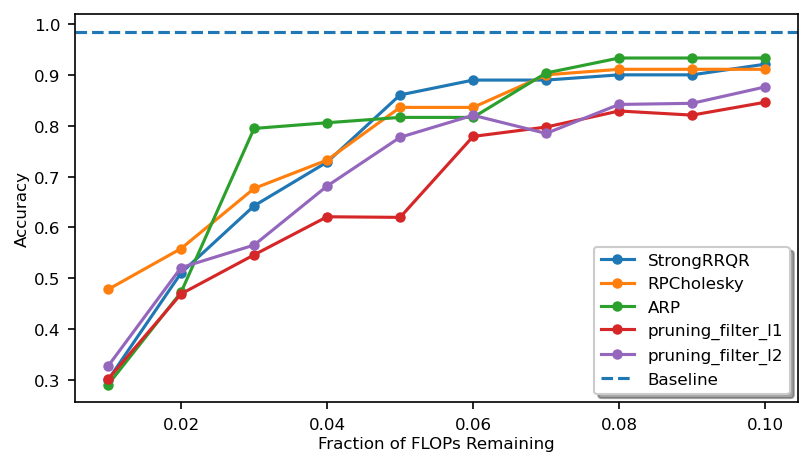

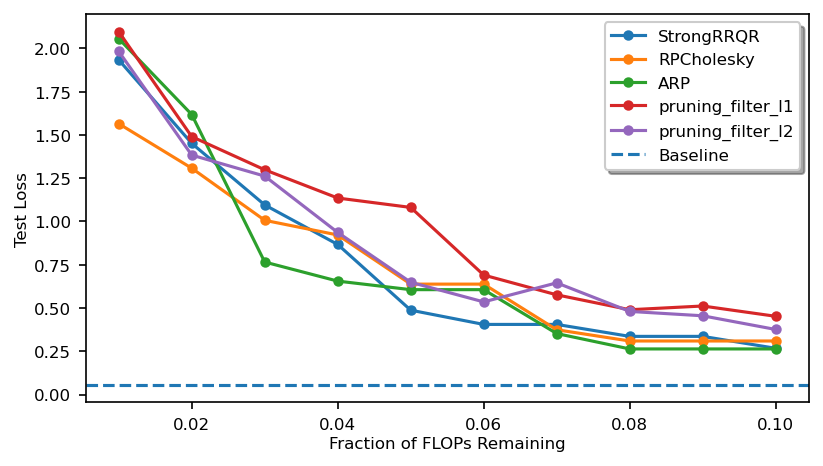

In [38]:
methods_CSSP = ["StrongRRQR", "RPCholesky", "ARP"]


rho = np.linspace(0.1, 0.01, 10)
methods_flops = methods_CSSP + ["pruning_filter_l1", "pruning_filter_l2"]
all_accs = []
all_losses = []
layerwise_results = {}
pruned_models_dict = {}

# Run CSSP pruning methods
for method in methods_CSSP:
    accs = []
    model_CSSP, accs, losses, hist, pruned_models = iterative_pruning(copy.deepcopy(model2), X, (1, 28, 28), rho, 0.8, method, "flops", test_loader, train_loader)
    all_accs.append(accs)
    all_losses.append(losses)
    layerwise_results[method] = hist
    pruned_models_dict[method] = pruned_models

# Run pruning filter methods
filter_accs = []
filter_losses = []
for norm in ["l1", "l2"]:
    with contextlib.redirect_stdout(io.StringIO()):
        model_filter, filter_accs, filter_losses, filter_hist, filter_pruned_models = iterative_pruning_filter(
            model0=copy.deepcopy(model2),
            X=X,
            input_shape=(1, 28, 28),
            rho=rho,
            norm=norm,
            step_size=0.95,
            test_loader=test_loader,
            train_loader=train_loader
        )
    all_accs.append(filter_accs)
    all_losses.append(filter_losses)
    layerwise_results[f"pruning_filter_{norm}"] = filter_hist
    pruned_models_dict[f"pruning_filter_{norm}"] = filter_pruned_models


# Plot pruning curves
plot_pruning_curve(
    base_acc,
    rho,
    all_accs,
    methods_flops,
    "flops",
    "Accuracy"
)

plot_pruning_curve(
    base_loss,
    rho,
    all_losses,
    methods_flops,
    "flops",
    "Test Loss"
)

In [39]:
params = extract_params(model2.model)

for i, layer in enumerate(params):
    print(
        f"local_idx={i}, "
        f"layer_type={layer['layer_type']}, "
        f"global_idx={layer['layer_idx']}"
    )

local_idx=0, layer_type=Conv2d, global_idx=0
local_idx=1, layer_type=Conv2d, global_idx=3
local_idx=2, layer_type=Flatten, global_idx=6
local_idx=3, layer_type=Linear, global_idx=7
local_idx=4, layer_type=Linear, global_idx=9


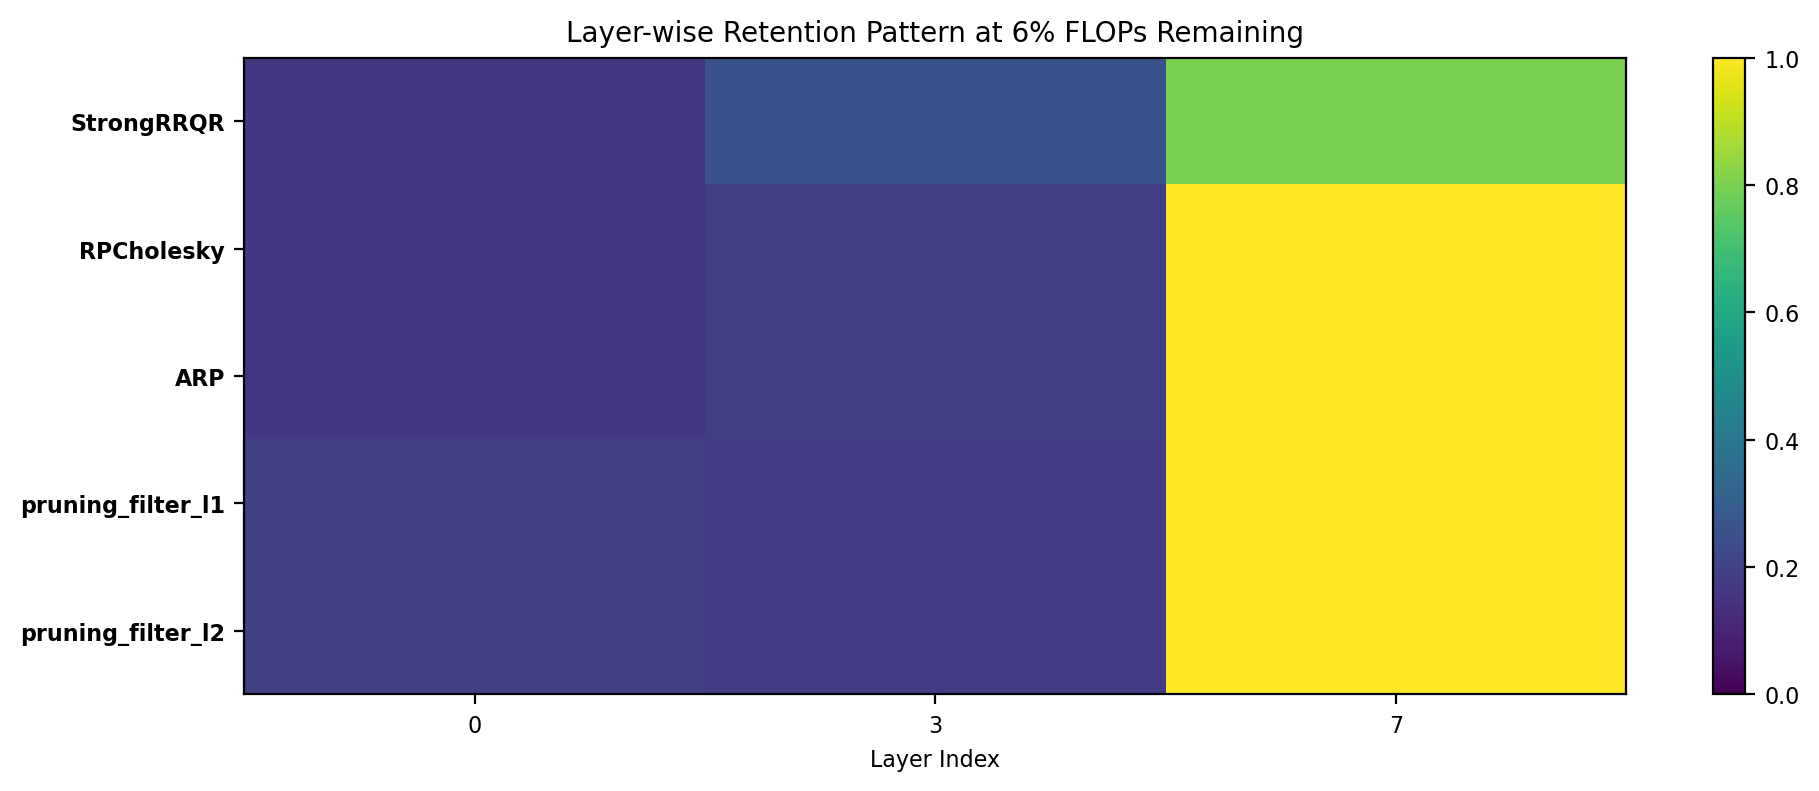

In [40]:
# plot layerwise pruning results at 10% FLOPs
heatmap_data = {
    method: layerwise_results[method]["0.06"]
    for method in methods_flops
}

plot_layerwise_retention_heatmap(
    heatmap_data,
    title="Layer-wise Retention Pattern at 6% FLOPs Remaining"
)

torch.Size([1024, 64])


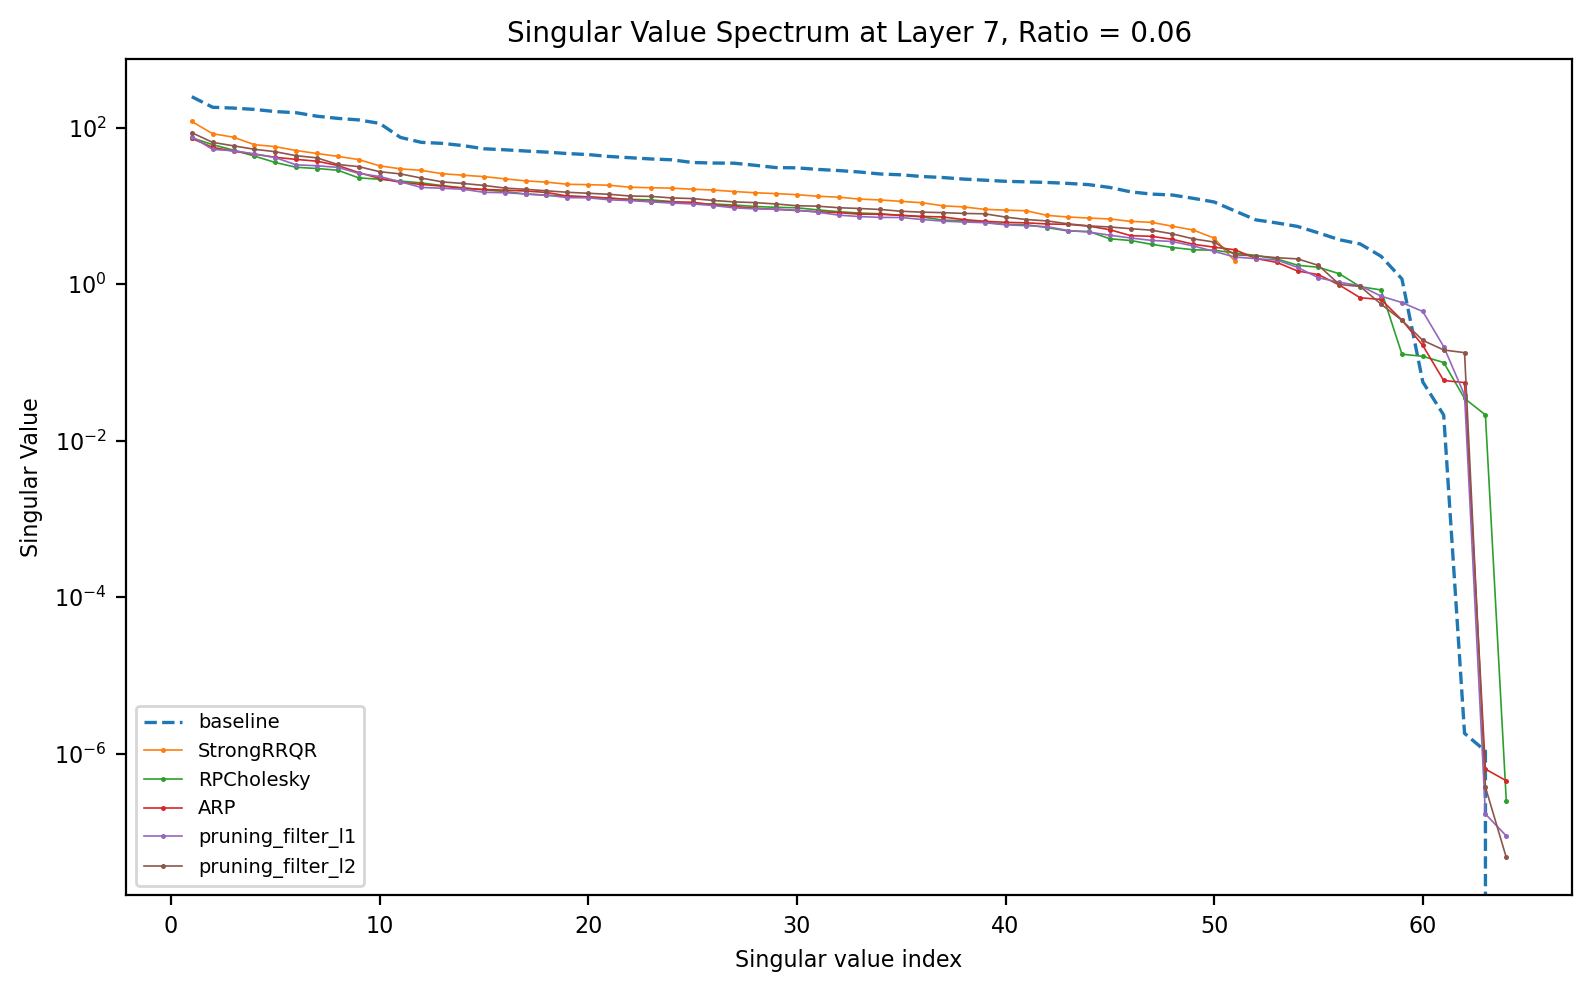

In [42]:
singular_values_dict = plot_singular_values(
    pruned_models_dict=pruned_models_dict,
    model_baseline=model2,
    params_base=params,
    X=X,
    l=3,
    rho_key="0.06",
    methods=methods_flops,
    device=device,
    log_scale=True,
    normalize=None,
)

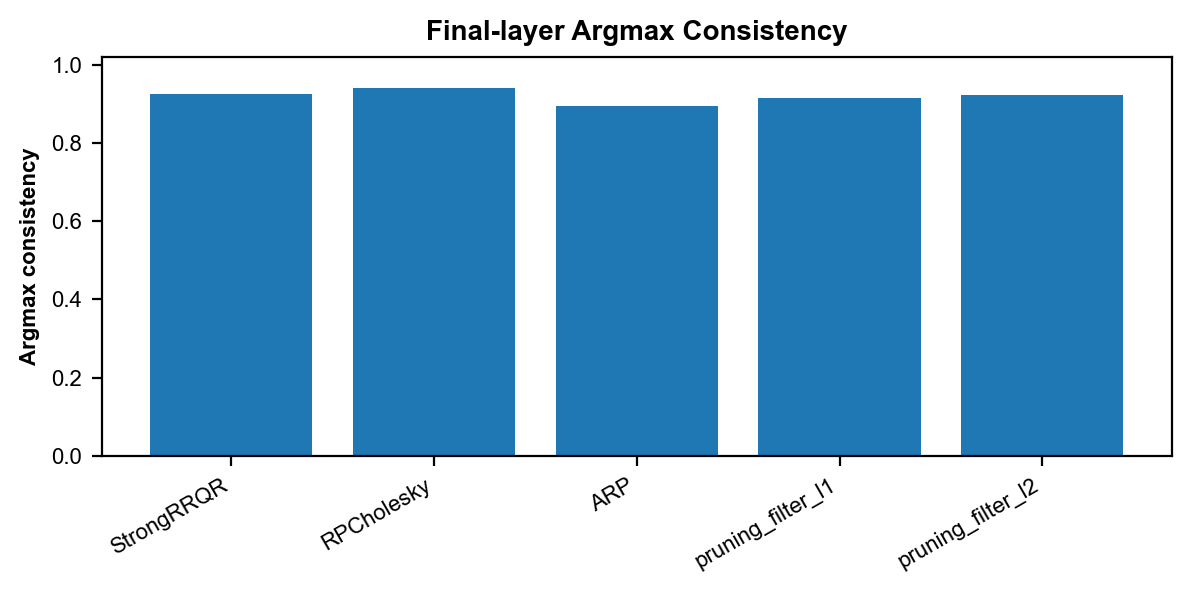

In [94]:
import importlib
import Plot as Plot
import Pruning.pruning_CSSP as pruning_CSSP

importlib.reload(Plot)
importlib.reload(pruning_CSSP)

last_layer_idx = 4

pruning_CSSP.get_layer_activation_matrix(model2, X, params, last_layer_idx)

activation_matrices = {}

# baseline
activation_matrices["baseline"] = pruning_CSSP.get_layer_activation_matrix(
    model2, X, params, last_layer_idx
).detach().cpu()

# pruned models
for method in methods_flops:
    model = pruned_models_dict[method]["0.10"]
    params_pruned = extract_params(model.model)

    activation_matrices[method] = pruning_CSSP.get_layer_activation_matrix(
        model, X, params_pruned, last_layer_idx
    ).detach().cpu()


results = Plot.plot_argmax_consistency(activation_matrices)

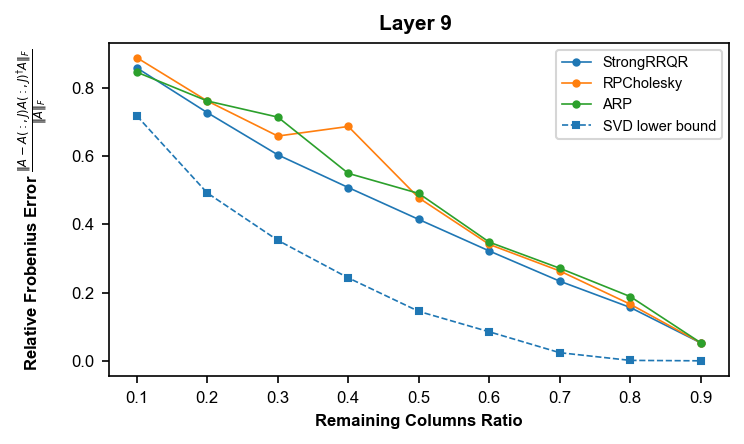

In [95]:
keep_ratios = np.arange(0.1, 1.0, 0.1)

relerr_results = compare_fixed_layer_relerr(model2, X, last_layer_idx, methods_CSSP, keep_ratios)

svd_bound = compute_svd_lower_bound(A, keep_ratios)

Plot.plot_fixed_layer_relerr(
    relerr_results,
    keep_ratios,
    params[last_layer_idx]["layer_idx"],
    svd_bound=svd_bound,
    title=(f"Layer {params[last_layer_idx]['layer_idx']} ")
)